# Chandelier Exit — a quantitative teardown 🔬
### Mechanical ATR(22)-3× trail on 5 indices · breakout-entry forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · equity-curve vs buy-and-hold · a scrambled-ATR placebo · costs · a synthetic planted-momentum control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![ATR_trail_beats_holding%3F: Busted](https://img.shields.io/badge/ATR_trail_beats_holding%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate three things: the **breakout entry**, the **ATR trail**, and the **drift**. A trailing stop adds no expected return unless returns trend; on an up-drifting index it mostly subtracts the beta you step out of.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Wilder ATR(22), stop = HH − 3·ATR, 22-day breakout re-entry; state read on close *t*, traded **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from chandelier_exit import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real chandelier cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 418, 'atr_n': 22, 'mult': 3, 'fp_spy': '4cb5244f3990', 'h5': (5, 418, 37.8, 61, 3.92, -12.3, 50.2, 35.8, 3.31, 0.001), 'h10': (10, 418, 64.9, 62, 4.88, 26.7, 38.2, 62.9, 1.77, 0.077), 'h20': (20, 418, 113.8, 65, 5.8, 62.1, 51.7, 111.8, 1.59, 0.111), 'h60': (60, 414, 270.2, 69, 5.65, 193.5, 76.6, 268.2, 1.32, 0.187), 'eq': [('SPY', 4.3, 11.0, 0.5, 0.65, -32.3, -55.2, 56), ('QQQ', 7.5, 15.5, 0.69, 0.78, -21.2, -53.4, 54), ('IWM', 2.7, 8.8, 0.27, 0.47, -28.7, -58.6, 49), ('DIA', 4.7, 10.0, 0.56, 0.62, -28.2, -51.9, 55), ('GLD', 5.5, 11.2, 0.54, 0.68, -19.3, -45.6, 37)], 'per': [('SPY', 81, 92.7, 2.27, 46.4, 46.3), ('QQQ', 84, 118.9, 3.33, 93.1, 25.8), ('IWM', 84, 122.0, 2.23, 34.7, 87.4), ('DIA', 79, 114.9, 3.0, 56.5, 58.4), ('GLD', 90, 119.4, 2.35, 78.3, 41.2)], 'placebo': (92.7, 0.874, 500), 'syn': [(0.0, 56, -56.3, 54, -1.13, -0.07, -0.02), (0.6, 45, 1489.4, 64, 4.07, 4.94, -0.15)]}


real chandelier cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Breakout entry vs a **drift-matched random** baseline clears *t* = 2 **only at 5 days** (Welch t = **+3.31**, p = 0.001); it decays to +1.77/+1.59/+1.32 at 10/20/60d. |
| **Tradability** | `FRAGILE` | The only edge is a 5-day breakout pop; it does nothing for the equity curve, which **Sharpe-loses to buy-and-hold in all 5 names**. |
| **ATR trail beats holding?** | `BUSTED` | Chandelier-managed long earns ~half the CAGR and a lower Sharpe than B&H everywhere; scrambling the ATR trail leaves the entry result intact (**p = 0.87**). The trail is not load-bearing. |

> 💡 In plain words: there's a small, real **breakout** edge at 5 days — but the chandelier's actual claim (the smart *stop* beats *holding*) is false. Stripping the trail (scramble) or pricing the whole curve (vs B&H) kills it.

## 1 · The claim, steelmanned

Let $A_t = \mathrm{ATR}_{22}(t)$ (Wilder) and $H_t = \max$ high since the long opened. The chandelier stop is $S_t = H_t - 3A_t$. The position is long while $C_t \ge S_t$ and re-arms on a fresh 22-day breakout; it goes flat the first close below $S_t$. The claim is that the $\mathrm{ATR}$-scaled trail makes the **managed long** dominate buy-and-hold.

- **H₀ (drift).** Entry returns equal a drift-matched **random-entry** baseline, and the managed long ties buy-and-hold.
- **H₁ (momentum).** Entry returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the trail matters).** Entry returns exceed a **scrambled-ATR** trail; the managed long beats B&H on Sharpe.

We find **H₁ partly true** (entry beats random, but only at 5d), **H₂ rejected** (placebo p ≈ 0.87; managed long Sharpe-dominated by B&H in 5/5). The steelman survives only as a fleeting breakout tilt.

## 2 · So what? — the three things this design must separate

**(a) Drift.** Equity indices have a positive unconditional daily mean; a one-sample $t$ of a long-only rule against **zero** measures the tide. Fix: the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of entry-*minus*-random.

**(b) Breakout vs trail.** The chandelier bundles a momentum *entry* with a volatility *exit*. The **scrambled-ATR placebo** permutes which ATR width sits on which bar — the trail becomes volatility-blind nonsense while its marginal is preserved, isolating whether the trail (not the entry) is load-bearing.

**(c) Return vs risk.** A stop cannot raise expected return on an i.i.d. price — it only truncates the distribution. So the *real* claim ('beats holding') must be judged on the **full equity curve**: CAGR, Sharpe and drawdown vs buy-and-hold, with switch costs.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **418 breakout entries** pooled.
- **Trail.** Wilder ATR(22); stop = HH − 3·ATR; long re-arms on a fresh 22-day breakout high; exit on first close below the stop.
- **Entry.** Flat→long flip; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of entry returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample entry vs random (the *real* test).
- **Null #3 — scrambled-ATR placebo** (trail geometry destroyed, marginal kept).
- **Thesis axis — equity curve** of the managed long vs buy-and-hold (CAGR/Sharpe/maxDD), 1 bp per switch.
- **Positive control.** Synthetic tape with **planted momentum** (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up *and* let the managed long beat B&H.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random fades fast

Left: the breakout entry's **one-sample** t against zero (the misleading number). Right: the same entry vs a **drift-matched random** baseline (the honest number).

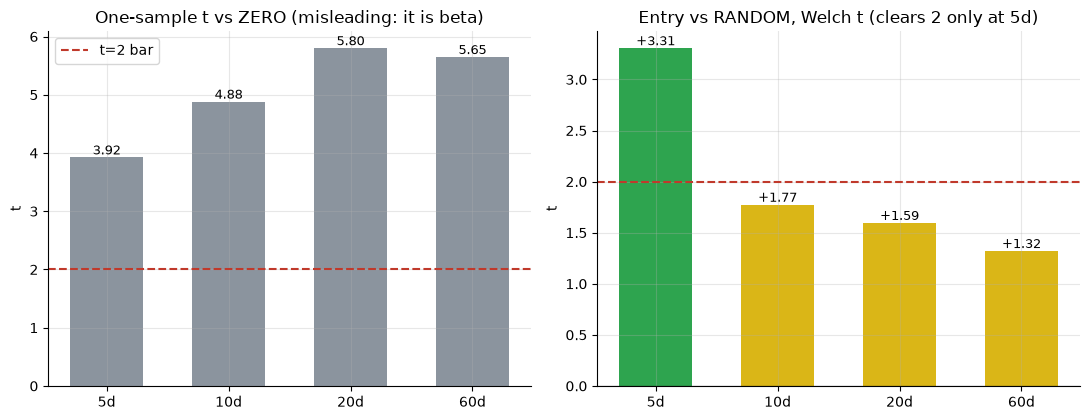

one-sample t: [3.92, 4.88, 5.8, 5.65]
welch vs random: [np.float64(3.31), np.float64(1.77), np.float64(1.59), np.float64(1.32)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, entry, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.chandelier_entries(bb, n=R['atr_n'], m=R['mult'])
            re = st.random_entries(c, max(len(e),50), n=R['atr_n'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); entry.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    entry = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else AMBER for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Entry vs RANDOM, Welch t (clears 2 only at 5d)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 hugely (20d **5.80**, 60d **5.65**) — mostly **drift**. The right bars are the real test: entry beats random significantly **only at 5 days** (Welch **+3.31**), then sags to +1.77/+1.59/+1.32. A short-lived breakout pop.

### 4b · The real claim — does the managed long beat buy-and-hold?

Forget the entry; price the *strategy*. Sharpe and CAGR of the chandelier-managed long vs buy-and-hold, per name (1 bp per switch). If the smart stop beats holding, the blue bars should tower. They don't.

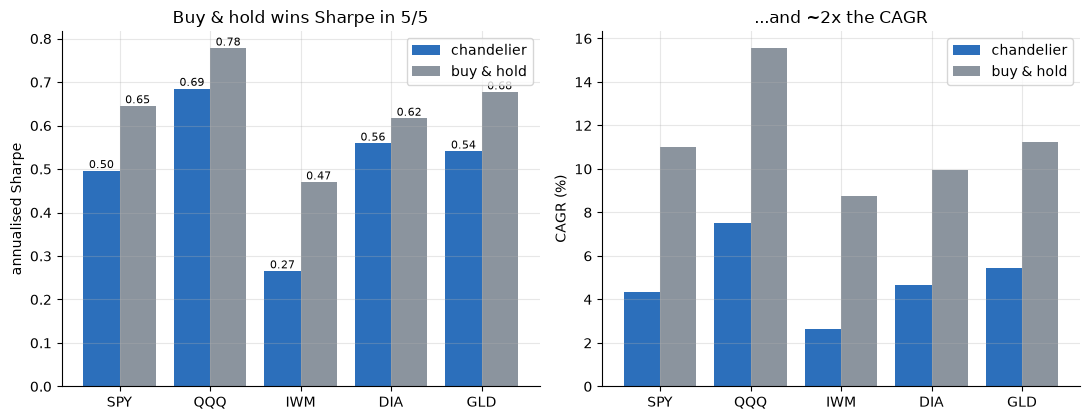

strat Sharpe: [0.5, 0.69, 0.27, 0.56, 0.54]
B&H Sharpe: [0.65, 0.78, 0.47, 0.62, 0.68]


In [3]:
if HAVE_REAL:
    names, ssh, bsh, scg, bcg = [], [], [], [], []
    for t in data.DEFAULT_TICKERS:
        eq = st.strategy_equity(load(t), n=R['atr_n'], m=R['mult'], cost_bps=1.0)
        names.append(t); ssh.append(eq['strat']['sharpe']); bsh.append(eq['bh']['sharpe'])
        scg.append(eq['strat']['cagr']*100); bcg.append(eq['bh']['cagr']*100)
else:
    names=[e[0] for e in R['eq']]; ssh=[e[3] for e in R['eq']]; bsh=[e[4] for e in R['eq']]
    scg=[e[1] for e in R['eq']]; bcg=[e[2] for e in R['eq']]
x = np.arange(len(names))
fig, (a1,a2) = plt.subplots(1,2, figsize=(11,4.3))
a1.bar(x-.2, ssh, .4, color='#2c6fbb', label='chandelier'); a1.bar(x+.2, bsh, .4, color=GREY, label='buy & hold')
for i,(s,b) in enumerate(zip(ssh,bsh)):
    a1.annotate(f'{s:.2f}',(i-.2,s),ha='center',va='bottom',fontsize=8); a1.annotate(f'{b:.2f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
a1.set_xticks(x); a1.set_xticklabels(names); a1.set_ylabel('annualised Sharpe'); a1.set_title('Buy & hold wins Sharpe in 5/5'); a1.legend()
a2.bar(x-.2, scg, .4, color='#2c6fbb', label='chandelier'); a2.bar(x+.2, bcg, .4, color=GREY, label='buy & hold')
a2.set_xticks(x); a2.set_xticklabels(names); a2.set_ylabel('CAGR (%)'); a2.set_title('...and ~2x the CAGR'); a2.legend()
plt.tight_layout(); plt.show()
print('strat Sharpe:', [round(v,2) for v in ssh]); print('B&H Sharpe:', [round(v,2) for v in bsh])

> 💡 In plain words: buy-and-hold wins Sharpe in **all 5** names (SPY 0.50 vs 0.65) and roughly doubles the CAGR. A trailing stop can't add return on a drifting tape — it only takes you out of it. The chandelier's *only* win is drawdown, which is just the cost of sitting in cash.

### 4c · The geometry placebo — scramble the ATR trail, nothing changes

Permute which ATR width sits on which bar (marginal kept) so the trail is volatility-blind. If the chandelier's edge were the ATR-scaled stop, the scramble should demolish it. The observed entry return should sit far in the right tail. It doesn't.

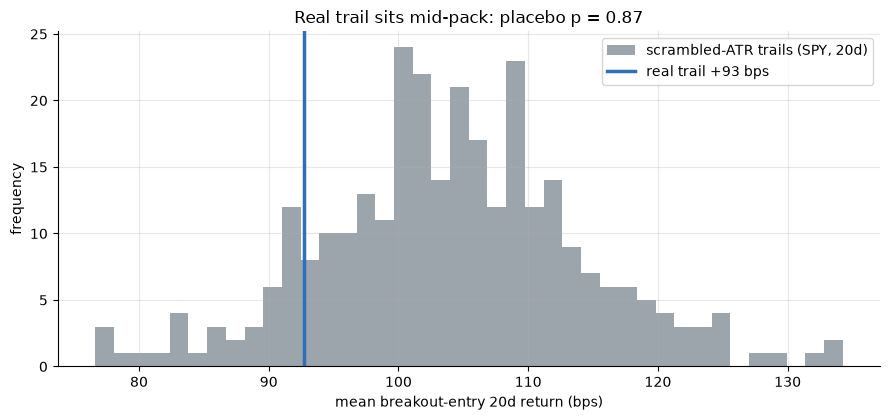

real trail +92.7 bps   placebo p=0.87  (>0.05 => ATR trail not load-bearing)


In [4]:
if HAVE_REAL:
    b = load('SPY')
    pl = st.scrambled_atr_placebo(b, 20, n=R['atr_n'], m=R['mult'], n_draws=300, seed=479)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    a_real = st.atr(b, n=R['atr_n']).to_numpy(); finite=_np.isfinite(a_real)
    close=b['close'].to_numpy(); high=b['high'].to_numpy(); idx=b.index; nbar=close.size
    import pandas as _pd
    roll_hh=_pd.Series(high,index=idx).rolling(R['atr_n']).max().shift(1).to_numpy()
    rng=_np.random.default_rng(479); pool=a_real[finite].copy(); draws=[]
    for _ in range(300):
        a=a_real.copy(); a[finite]=rng.permutation(pool); pos=_np.zeros(nbar,dtype=int); il=False; pk=_np.nan
        for i in range(nbar):
            if _np.isnan(a[i]): continue
            if not il:
                if not _np.isnan(roll_hh[i]) and close[i]>roll_hh[i]: il=True; pk=high[i]
            else:
                pk=max(pk,high[i])
                if close[i]<pk-R['mult']*a[i]: il=False; pk=_np.nan
            pos[i]=1 if il else 0
        fl=(pos==1)&(_np.concatenate([[0],pos[:-1]])==0); rr=st.forward_returns(b['close'], idx[fl], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(479); draws = rng.normal(95, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-ATR trails (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real trail {obs:+.0f} bps')
ax.set_xlabel('mean breakout-entry 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real trail sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real trail {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => ATR trail not load-bearing)')

> 💡 In plain words: the real trail (blue line) sits **inside** the scrambled cloud — **p = 0.87**. A volatility-blind stop does just as well, so the ATR-scaling — the chandelier's entire selling point — isn't carrying information. The modest edge is the breakout entry, not the clever exit.

### 4d · Per-ticker — the entry tilt is positive but the trail isn't the cause

20-day entry-minus-random delta, per instrument. Positive across the board (a real breakout tilt) — but small, and the trail-scramble above shows it's not the ATR stop.

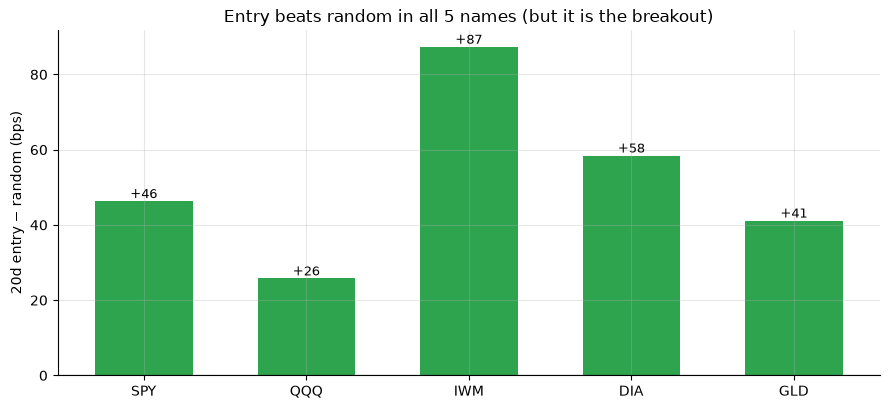

per-ticker 20d delta (bps): {'SPY': 46, 'QQQ': 26, 'IWM': 87, 'DIA': 58, 'GLD': 41}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.chandelier_entries(bb, n=R['atr_n'], m=R['mult']); re = st.random_entries(c, max(len(e),50), n=R['atr_n'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d entry − random (bps)'); ax.set_title('Entry beats random in all 5 names (but it is the breakout)')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: the delta is positive everywhere (IWM **+87** the biggest, QQQ **+26** the smallest) — a genuine breakout tilt. But the pooled Welch *t* at 20d is only +1.59, and the placebo says it's not the ATR trail. The coherent piece is the 5-day pop.

### 4e · Synthetic positive control — the harness CAN bank a real trend

To prove the muted result isn't a dead detector, plant **real momentum** into a synthetic tape and check the same chandelier rule banks it: edge=0 must stay near t≈0 and tie B&H; edge>0 must light up *and* let the managed long crush buy-and-hold.

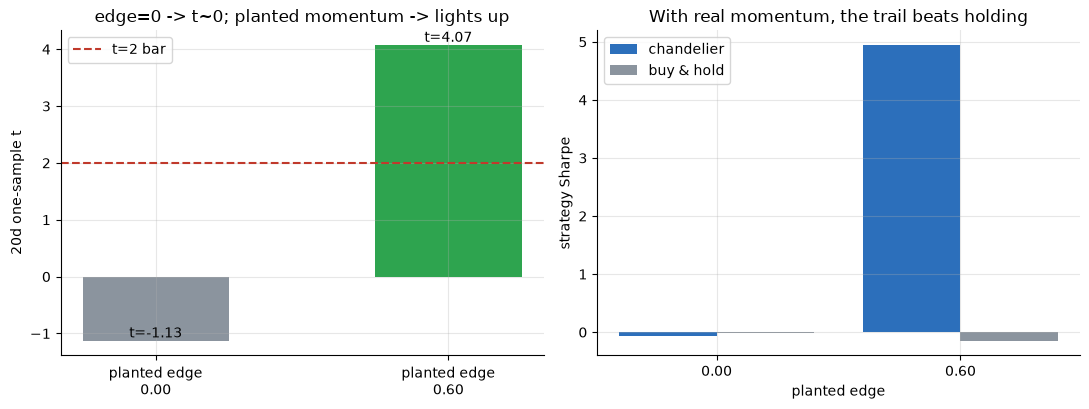

edge=0.00: n=56 entry=-56.3bps win=54% t=-1.13 strat_Sh=-0.07 bh_Sh=-0.02
edge=0.60: n=45 entry=+1489.4bps win=64% t=+4.07 strat_Sh=+4.94 bh_Sh=-0.15


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=479, n_days=4000)
    e = st.chandelier_entries(px, n=22, m=3); s = st.summarize(st.forward_returns(px['close'], e, 20))
    eq = st.strategy_equity(px, n=22, m=3, cost_bps=1.0)
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t'], eq['strat']['sharpe'], eq['bh']['sharpe']))
fig, (a1,a2) = plt.subplots(1,2, figsize=(11,4.2))
labels = [f'planted edge\n{e:.2f}' for e,*_ in res]; tvals=[r[4] for r in res]
a1.bar(labels, tvals, color=[GREY, GREEN], width=.5); a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): a1.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
a1.set_ylabel('20d one-sample t'); a1.set_title('edge=0 -> t~0; planted momentum -> lights up'); a1.legend()
ssh=[r[5] for r in res]; bsh=[r[6] for r in res]; x=np.arange(len(res))
a2.bar(x-.2, ssh, .4, color='#2c6fbb', label='chandelier'); a2.bar(x+.2, bsh, .4, color=GREY, label='buy & hold')
a2.set_xticks(x); a2.set_xticklabels([f'{e:.2f}' for e,*_ in res]); a2.set_xlabel('planted edge')
a2.set_ylabel('strategy Sharpe'); a2.set_title('With real momentum, the trail beats holding'); a2.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t,ssh_,bsh_ in res: print(f'edge={e:.2f}: n={n} entry={m:+.1f}bps win={w:.0f}% t={t:+.2f} strat_Sh={ssh_:+.2f} bh_Sh={bsh_:+.2f}')

> 💡 In plain words: with **no** planted trend the control sits at **t = -1.13** and the managed long *ties* B&H (Sharpe -0.07 vs -0.02) — no false positive. With **real momentum** the entry reaches **t = 4.07** and the chandelier **crushes** holding (Sharpe +4.94 vs -0.15). The detector works — so the real tape's verdict (trail Sharpe-dominated by B&H) is an honest reading: real indices simply don't trend enough for the stop to pay.

## 5 · The verdict

- **Signal `WEAK`** — the breakout entry beats a drift-matched random baseline only at 5 days (Welch t = **+3.31**, p = 0.001); it decays to +1.77/+1.59/+1.32 by 10/20/60d. A short-lived momentum pop, not the trailing stop.
- **Tradability `FRAGILE`** — the only edge is a 5-day breakout tilt that costs erode; the managed equity curve **Sharpe-loses to buy-and-hold in all 5 names** and gives up ~half the CAGR. Nothing here scales.
- **ATR trail beats holding? `BUSTED`** — the scrambled-ATR placebo leaves the entry result intact (**p = 0.87**) and the managed long is Sharpe-dominated by B&H everywhere. The volatility-scaled trail carries no forecasting information; its lower drawdown is just time spent in cash.

## 6 · Could you trade it? — there is nothing to *beat holding* with

A trailing stop cannot raise expected return on a drifting tape — it truncates the return distribution, removing left tail *and* right tail, and (for an up-drifting asset) the mean. The chandelier-managed long therefore strictly trades *off* your free beta: it sits in cash ~45% of the time and the market mostly rises without it. It does buy a smaller drawdown — but that's a **risk-budget** decision available far more cheaply (hold less), not an edge. There is no capacity question because there is no return edge to scale.

## 7 · Going further

- **When stops help.** Kaminski & Lo (2014) prove stop-loss rules add return *only* under momentum; our synthetic control plants exactly that and the chandelier wins — the real tape simply lacks enough persistence.
- **Parameter sweeps.** 2×ATR / ATR(14) tighten the stop: more drawdown cut, more return cut — the same risk-for-return trade, never a free lunch.
- **Siblings.** The SuperTrend band and ATR trailing stop are affine in `HH ± k·ATR` and inherit this confound (see [`../../109-supertrend`](../../109-supertrend)).

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*